In [1]:
# ============================================================================
#
# ============================================================================

# Step 1: Install compatible NumPy version
import sys
!{sys.executable} -m pip install numpy==2.0.2 -q

# Step 2: Reinstall scikit-learn with the correct NumPy
!{sys.executable} -m pip install --force-reinstall --no-cache-dir scikit-learn==1.6.1 -q

# Step 3: Install other libraries
!pip install -q librosa soundfile wordcloud gradio

print("✓ Packages installed, now importing...\n")

# Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Audio processing
import librosa
import soundfile as sf
import os
from glob import glob

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import sklearn

print("✓ All libraries imported successfully!")
print(f"\n📦 Versions:")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  Scikit-learn: {sklearn.__version__}")
print(f"  Librosa: {librosa.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 140.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 217.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 122.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 139.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 50.9 MB/s eta 0:00:00
✓ Packages installed, now importing...

✓ All libraries imported successfully!


In [2]:
!pip install -q git+https://github.com/speechbrain/speechbrain.git


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 26.6 MB/s eta 0:00:00


In [4]:



# Cell 2: Imports, settings, and paths
import os, glob, math, pickle, tempfile, warnings, random, time
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import librosa, soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.neighbors import NearestNeighbors

import torch
from speechbrain.pretrained import EncoderClassifier

warnings.filterwarnings("ignore")
sns.set()



AUDIO_ROOT = "../data/audio/"
QURAN_CSV_PATH = "../data/quran.csv"

EMBED_DB_PATH = "../models/embeddings_db.pkl"
CLASSIFIER_PATH = "../models/reciter_classifier.joblib"
CONTENT_INDEX_PATH = "../models/content_index_quran.npz"

SR = 16000
CHUNK_SEC = 6.0
CHUNK_HOP = 3.0
N_MFCC = 40
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("Audio folder exists:", os.path.exists(AUDIO_ROOT))
print("CSV file exists:", os.path.exists(QURAN_CSV_PATH))


Mounted at /content/drive
Device: cpu
Audio folder exists: True
CSV file exists: True


In [5]:
# Cell 3: Load quran_full.csv and prepare verse counts
if not os.path.exists(QURAN_CSV_PATH):
    raise FileNotFoundError(f"quran_full.csv not found at {QURAN_CSV_PATH}. Upload it or change the path.")

quran_df = pd.read_csv(QURAN_CSV_PATH, index_col=0)
expected_cols = ["Chapter Name", "Chapter Number", "Verse Number", "Arabic Text"]
if not all(c in quran_df.columns for c in expected_cols):
    raise ValueError(f"CSV missing expected columns. Found: {list(quran_df.columns)}; expected: {expected_cols}")

verses_per_surah = quran_df.groupby("Chapter Number")["Verse Number"].max().to_dict()
print("Loaded quran_full.csv, sample:", list(verses_per_surah.items())[:5])


Loaded quran_full.csv, sample: [(1, 7), (2, 286), (3, 200), (4, 176), (5, 120)]


In [6]:
# Cell 5: Whisper for transcription
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

print("Loading SpeechBrain ECAPA speaker model...")
spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    run_opts={"device": DEVICE}
)
spk_model.to(DEVICE)
spk_model.eval()
print("Speaker model loaded.")

# Load Whisper for Arabic transcription
print("Loading Whisper model for Arabic transcription...")
whisper_processor = WhisperProcessor.from_pretrained("openai/whisper-small")
whisper_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
whisper_model.to(DEVICE)
whisper_model.eval()
print("Whisper model loaded.")

import os
import glob
import re

def list_reciter_files(audio_root=AUDIO_ROOT):
    """Return list of (reciter_name, surah_number, filepath)"""
    files = []

    if not os.path.exists(audio_root):
        return files

    for reciter_dir in sorted(os.listdir(audio_root)):
        reciter_path = os.path.join(audio_root, reciter_dir)
        if not os.path.isdir(reciter_path):
            continue

        for ext in ("mp3", "wav", "flac", "ogg", "m4a"):
            for f in glob.glob(os.path.join(reciter_path, f"*.{ext}")):
                name = os.path.splitext(os.path.basename(f))[0]

                # Case 1: filename is just number (e.g., 067)
                if name.isdigit():
                    surah_num = int(name)

                else:
                    # Case 2: extract last number from filename (e.g., audio_ali_067)
                    match = re.search(r'(\d{1,3})(?!.*\d)', name)
                    if match:
                        surah_num = int(match.group(1))
                    else:
                        print(f"Skipping file (no surah number): {f}")
                        continue

                files.append((reciter_dir, surah_num, f))

    return files

def load_audio_file(path, sr=SR):
    y, _sr = librosa.load(path, sr=sr, mono=True)
    return y, sr

def compute_mfcc_embedding(y, sr=SR, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mean = mfcc.mean(axis=1)
    std = mfcc.std(axis=1)
    return np.concatenate([mean, std])

def compute_speaker_embedding(y, sr=SR):
    wav = torch.tensor(y, dtype=torch.float32).to(DEVICE).unsqueeze(0)
    with torch.no_grad():
        out = spk_model.encode_batch(wav)
    if isinstance(out, tuple):
        emb = out[0]
    else:
        emb = out
    emb = emb.squeeze().cpu().numpy()
    return emb

def transcribe_audio(y, sr=SR):
    """Transcribe audio to Arabic text using Whisper"""
    # Resample if needed (Whisper expects 16kHz)
    if sr != 16000:
        y = librosa.resample(y, orig_sr=sr, target_sr=16000)
        sr = 16000

    # Process audio
    input_features = whisper_processor(
        y,
        sampling_rate=sr,
        return_tensors="pt"
    ).input_features.to(DEVICE)

    # Generate transcription
    with torch.no_grad():
        predicted_ids = whisper_model.generate(
            input_features,
            language="ar",  # Force Arabic
            task="transcribe"
        )

    # Decode transcription
    transcription = whisper_processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    return transcription.strip()

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


Loading SpeechBrain ECAPA speaker model...


hyperparams.yaml: 0.00B [00:00, ?B/s]

INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Whisper model loaded.


In [7]:
#Text matching utilities
from difflib import SequenceMatcher
import re

def normalize_arabic_text(text):
    """Normalize Arabic text for better matching"""
    # Remove diacritics (tashkeel)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    # Normalize alef variations
    text = re.sub(r'[إأآا]', 'ا', text)
    # Remove extra spaces
    text = ' '.join(text.split())
    return text.strip()

def find_best_match(transcribed_text, quran_df, top_k=5):
    """
    Find best matching verses in Quran using fuzzy text matching
    Returns list of (surah, ayah, similarity_score, arabic_text)
    """
    normalized_input = normalize_arabic_text(transcribed_text)

    matches = []
    for idx, row in quran_df.iterrows():
        verse_text = normalize_arabic_text(row['Arabic Text'])

        # Calculate similarity
        similarity = SequenceMatcher(None, normalized_input, verse_text).ratio()

        # Also check if input is substring of verse (for partial matches)
        if normalized_input in verse_text:
            similarity = max(similarity, 0.9)

        matches.append({
            'surah': int(row['Chapter Number']),
            'surah_name': row['Chapter Name'],
            'ayah': int(row['Verse Number']),
            'similarity': similarity,
            'text': row['Arabic Text']
        })

    # Sort by similarity and return top k
    matches.sort(key=lambda x: x['similarity'], reverse=True)
    return matches[:top_k]

In [8]:
# Cell 6: Build embedding DB with transcriptions (NO CHUNKS)
def build_db(audio_root=AUDIO_ROOT, rebuild=False):
    if os.path.exists(EMBED_DB_PATH) and not rebuild:
        print("Loading existing DB:", EMBED_DB_PATH)
        return pickle.load(open(EMBED_DB_PATH, "rb"))

    files = list_reciter_files(audio_root)
    print(f"Found {len(files)} files across reciters.")
    records = []

    for i, (reciter, surah_num, fpath) in enumerate(files):
        try:
            y, sr = load_audio_file(fpath)
        except Exception as e:
            print("Failed to load:", fpath, e)
            continue

        duration = len(y)/sr

        # Speaker embedding (for reciter identification)
        # Use only the first 30 seconds to avoid GPU out-of-memory on long surahs
        try:
            max_spk_duration = 30
            if len(y) > max_spk_duration * sr:
                y_spk = y[:int(max_spk_duration * sr)]
            else:
                y_spk = y
            spk_emb = compute_speaker_embedding(y_spk, sr)
        except Exception as e:
            print("SPK emb failed for", fpath, e)
            continue

        # Transcribe full surah audio
        try:
            print(f"Transcribing {reciter} - Surah {surah_num}... ({duration:.1f}s)")
            transcription = transcribe_audio(y, sr)
            print(f"  → {transcription[:100]}...")
        except Exception as e:
            print("Transcription failed for", fpath, e)
            transcription = ""

        records.append({
            "reciter": reciter,
            "surah": surah_num,
            "path": fpath,
            "duration": duration,
            "spk_emb": spk_emb,
            "transcription": transcription,
            "ground_truth_surah": surah_num  # Store known surah number
        })

        if (i+1) % 5 == 0:
            print(f"Processed {i+1}/{len(files)}")

    db = {"records": records}
    pickle.dump(db, open(EMBED_DB_PATH, "wb"))
    print("Saved DB to", EMBED_DB_PATH)
    return db

# Run build (set rebuild=True to include transcriptions)
db = build_db(AUDIO_ROOT, rebuild=True)
print("Records in DB:", len(db["records"]))

Found 30 files across reciters.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Transcribing abdulbasit_abdulsamad - Surah 67... (853.3s)


A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


  → بسم الله الرحمن الرحيم تبارك الأذي بيده الملك وعلى كل شيء قلير...
Transcribing abdulbasit_abdulsamad - Surah 109... (91.1s)
  → بسم الله الرحمن الرحيم قل يا أيها الكافرون...
Transcribing abdulbasit_abdulsamad - Surah 110... (62.1s)
  → بسم الله الرحمن الرحيم إذا جاء نصر الله والفتح...
Transcribing abdulbasit_abdulsamad - Surah 112... (41.4s)
  → بسم الله الرحمن الرحيب قله الله أحد الله الصمد لم يلد ولم يولد...
Transcribing abdulbasit_abdulsamad - Surah 113... (63.6s)
  → بسم الله الرحمن الرحيم...
Processed 5/30
Transcribing abdulbasit_abdulsamad - Surah 114... (83.0s)
  → 2. بسم الله الرحمن الرحيم 3. قل أعوذ برب الناس 4. ملك الناس...
Transcribing abdulrahman_sudias - Surah 112... (14.0s)
  → بسم الله الرحمن الرحيم...
Transcribing abdulrahman_sudias - Surah 110... (23.5s)
  → بسم الله الرحمن الرحيم...
Transcribing abdulrahman_sudias - Surah 111... (25.7s)
  → بسم الله الرحمن الرحيم تكبت يدى أبي لهبي وتبى ما أرنا عنه ماله وما كسب سيصلى نارا ذات لهب ومرت رحمنا...
Transcribing abdulrah

In [9]:
# NEW CELL: Load labels CSV and attach labels to records
import pandas as pd
import os

LABELS_CSV_PATH = "/content/drive/MyDrive/CS316 PROJECT/audio_labels.csv"

labels_df = pd.read_csv(LABELS_CSV_PATH)
print("Loaded labels:")
print(labels_df.head())
print("Total rows:", len(labels_df))

label_map = {}
for _, row in labels_df.iterrows():
    key = (str(row["filename"]).strip(), str(row["reciter"]).strip())
    label_map[key] = {
        "surah": int(row["surah"]),
        "start_ayah": int(row["start_ayah"]),
        "end_ayah": int(row["end_ayah"]),
    }

for rec in db["records"]:
    base = os.path.basename(rec["path"]).strip()
    reciter = str(rec["reciter"]).strip()
    rec["label_info"] = label_map.get((base, reciter), None)

count = sum(1 for r in db["records"] if r.get("label_info") is not None)
print("Labels attached:", count, "/", len(db["records"]))


Loaded labels:
  filename                reciter  surah  start_ayah  end_ayah
0  067.mp3  abdulbasit_abdulsamad     67           1        30
1  109.mp3  abdulbasit_abdulsamad    109           1         6
2  110.mp3  abdulbasit_abdulsamad    110           1         3
3  112.mp3  abdulbasit_abdulsamad    112           1         4
4  113.mp3  abdulbasit_abdulsamad    113           1         5
Total rows: 30
Labels attached: 30 / 30


In [10]:

# NEW CELL: Check reciter folders and detect inconsistency
from collections import Counter
from glob import glob

def inspect_dataset(audio_root=AUDIO_ROOT):
    print("=" * 70)
    print("DATASET INSPECTION")
    print("=" * 70)

    if not os.path.exists(audio_root):
        print(f"Audio root does not exist: {audio_root}")
        return []

    reciter_dirs = []
    for item in sorted(os.listdir(audio_root)):
        full_path = os.path.join(audio_root, item)
        if os.path.isdir(full_path):
            files = []
            for ext in ("mp3", "wav", "flac", "ogg", "m4a"):
                files.extend(glob(os.path.join(full_path, f"*.{ext}")))
            reciter_dirs.append((item, len(files), files[:3]))

    print(f"Detected reciter folders: {len(reciter_dirs)}\n")
    for name, count, sample_files in reciter_dirs:
        print(f"Reciter folder: {name}")
        print(f"Number of files: {count}")
        if sample_files:
            print("Sample files:", [os.path.basename(f) for f in sample_files])
        else:
            print("No valid audio files found in this folder.")
        print("-" * 50)

    print("\nSummary:")
    counts = {name: count for name, count, _ in reciter_dirs}
    print(counts)
    return reciter_dirs

reciter_dirs_info = inspect_dataset(AUDIO_ROOT)


DATASET INSPECTION
Detected reciter folders: 5

Reciter folder: abdulbasit_abdulsamad
Number of files: 6
Sample files: ['067.mp3', '109.mp3', '110.mp3']
--------------------------------------------------
Reciter folder: abdulrahman_sudias
Number of files: 6
Sample files: ['112.mp3', '110.mp3', '111.mp3']
--------------------------------------------------
Reciter folder: ali_hudhaify
Number of files: 6
Sample files: ['audio_ali_hudhaify_067.mp3', 'audio_ali_hudhaify_087.mp3', 'audio_ali_hudhaify_109.mp3']
--------------------------------------------------
Reciter folder: islam_sobhi
Number of files: 6
Sample files: ['088.mp3', '076.mp3', '067.mp3']
--------------------------------------------------
Reciter folder: mishary_al_afasy
Number of files: 6
Sample files: ['067.mp3', '100.mp3', '104.mp3']
--------------------------------------------------

Summary:
{'abdulbasit_abdulsamad': 6, 'abdulrahman_sudias': 6, 'ali_hudhaify': 6, 'islam_sobhi': 6, 'mishary_al_afasy': 6}


Number of unique reciters: 5
Top reciters by file count: [('abdulbasit_abdulsamad', 6), ('abdulrahman_sudias', 6), ('ali_hudhaify', 6), ('islam_sobhi', 6), ('mishary_al_afasy', 6)]


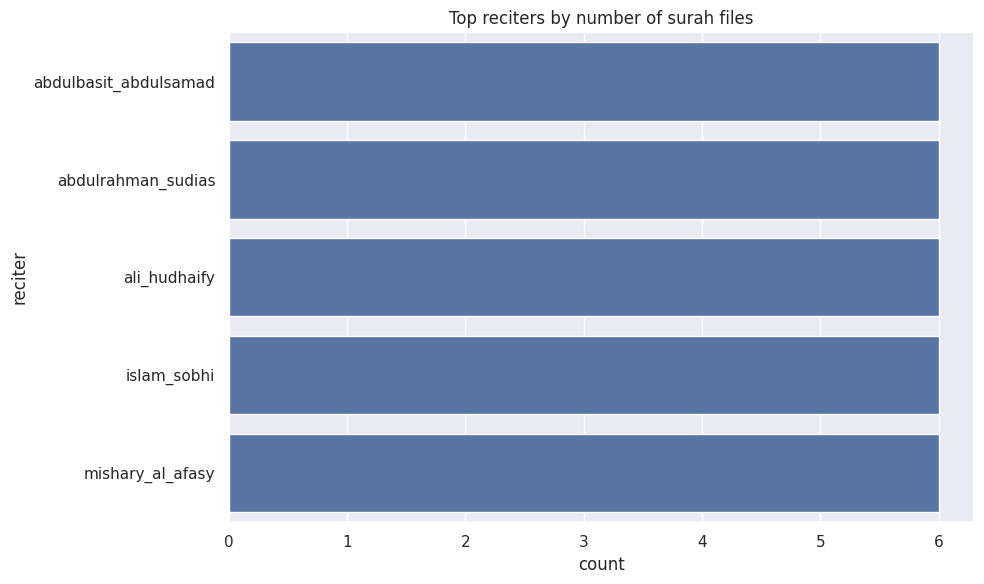


Example record keys: dict_keys(['reciter', 'surah', 'path', 'duration', 'spk_emb', 'transcription', 'ground_truth_surah', 'label_info'])
Reciter: abdulbasit_abdulsamad Surah: 67 Duration: 853.3420625
Transcription sample: بسم الله الرحمن الرحيم تبارك الأذي بيده الملك وعلى كل شيء قلير


In [11]:
# NEW CELL: EDA - reciter counts and example record
from collections import Counter
reciter_counts = Counter([r["reciter"] for r in db["records"]])
print("Number of unique reciters:", len(reciter_counts))
print("Top reciters by file count:", reciter_counts.most_common(10))

if reciter_counts:
    df_top = pd.DataFrame(reciter_counts.most_common(), columns=["reciter", "count"])
    plt.figure(figsize=(10, 6))
    sns.barplot(y="reciter", x="count", data=df_top)
    plt.title("Top reciters by number of surah files")
    plt.tight_layout()
    plt.show()

if len(db["records"]) > 0:
    example = db["records"][0]
    print("\nExample record keys:", example.keys())
    print("Reciter:", example["reciter"], "Surah:", example["surah"], "Duration:", example["duration"])
    print("Transcription sample:", example["transcription"][:200] if example["transcription"] else "None")


In [12]:
# NEW CELL: Train speaker-embedding reciter classifier for inference
X = []
y = []
for rec in db["records"]:
    X.append(rec["spk_emb"])
    y.append(rec["reciter"])

X = np.vstack(X)
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Unique reciters:", len(le.classes_))

try:
    X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=SEED)
except Exception:
    X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=SEED)

clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
clf.fit(X_train, y_train)
pickle.dump({"clf": clf, "le": le}, open(CLASSIFIER_PATH, "wb"))
print("Saved classifier to", CLASSIFIER_PATH)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
print(f"Val metrics -> acc={acc:.3f}, prec={prec:.3f}, rec={rec:.3f}, f1={f1:.3f}")


Unique reciters: 5
Saved classifier to /content/reciter_classifier.pkl
Val metrics -> acc=1.000, prec=1.000, rec=1.000, f1=1.000


In [13]:

# NEW CELL: Inference utilities and enhanced text matching
model_pack = pickle.load(open(CLASSIFIER_PATH, "rb"))
clf = model_pack["clf"]
le = model_pack["le"]

def normalize_arabic_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[ً-ٰٟ]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'[ؤئ]', 'ء', text)
    text = ' '.join(text.split())
    return text.strip()

def find_best_match(transcribed_text, quran_df, top_k=5):
    if not transcribed_text or transcribed_text == "Error during transcription":
        return []

    normalized_input = normalize_arabic_text(transcribed_text)
    input_words = set(normalized_input.split())
    matches = []

    for _, row in quran_df.iterrows():
        verse_text = normalize_arabic_text(row['Arabic Text'])
        verse_words = set(verse_text.split())

        seq_similarity = SequenceMatcher(None, normalized_input, verse_text).ratio()
        word_overlap = len(input_words & verse_words) / len(input_words) if input_words and verse_words else 0

        substring_score = 0
        if normalized_input in verse_text:
            substring_score = 1.0
        elif len(normalized_input) > 20:
            words_list = normalized_input.split()
            words_to_check = min(5, len(words_list))
            for i in range(max(0, len(words_list) - words_to_check + 1)):
                segment = ' '.join(words_list[i:i+words_to_check])
                if segment in verse_text:
                    substring_score = 0.85
                    break

        final_score = 0.4 * seq_similarity + 0.4 * word_overlap + 0.2 * substring_score
        matches.append({
            'surah': int(row['Chapter Number']),
            'surah_name': row['Chapter Name'],
            'ayah': int(row['Verse Number']),
            'similarity': final_score,
            'text': row['Arabic Text'],
            'seq_sim': seq_similarity,
            'word_overlap': word_overlap,
            'substring': substring_score
        })

    matches.sort(key=lambda x: x['similarity'], reverse=True)
    return matches[:top_k]

def predict_from_clip(path, top_k=3, max_duration=30):
    y, sr = load_audio_file(path)

    if len(y) > max_duration * sr:
        print(f"Audio is {len(y)/sr:.1f}s, limiting to {max_duration}s for processing")
        y = y[:int(max_duration * sr)]

    duration = len(y) / sr
    print(f"Processing {duration:.1f}s of audio...")

    spk_emb = compute_speaker_embedding(y, sr)
    probs = clf.predict_proba(spk_emb.reshape(1, -1))[0]
    classes = le.inverse_transform(np.arange(len(probs)))
    top_idx = np.argsort(probs)[::-1][:top_k]
    reciter_preds = [(classes[i], float(probs[i])) for i in top_idx]

    try:
        print("Transcribing audio...")
        transcription = transcribe_audio(y, sr)
        print(f"Transcribed: {transcription[:100]}...")
    except Exception as e:
        print("Transcription error:", e)
        transcription = "Error during transcription"
        return reciter_preds, transcription, []

    try:
        print("Matching with Quran verses...")
        matches = find_best_match(transcription, quran_df, top_k=5)
    except Exception as e:
        print("Matching error:", e)
        matches = []

    return reciter_preds, transcription, matches

if len(db["records"]) > 0:
    test_file = db["records"][0]["path"]
    print("="*80)
    print("TESTING INFERENCE")
    print("="*80)
    print("Test file:", test_file)
    print("Ground truth - Reciter:", db["records"][0]["reciter"], "Surah:", db["records"][0]["surah"])
    print()
    rp, transcription, matches = predict_from_clip(test_file, top_k=3, max_duration=20)
    print("\n" + "="*80)
    print("RESULTS")
    print("="*80)
    print("\n1. RECITER PREDICTIONS:")
    for r, p in rp:
        print(f"   {r}: {p:.1%}")
    print(f"\n2. TRANSCRIPTION:\n   {transcription}")
    print("\n3. TOP MATCHED VERSES:")
    if matches:
        for i, m in enumerate(matches[:3], 1):
            print(f"\n   Match {i}:")
            print(f"   - Surah {m['surah']:3d} ({m['surah_name']}), Ayah {m['ayah']}")
            print(f"   - Similarity: {m['similarity']:.1%}")
            print(f"   - Text: {m['text'][:80]}...")
    else:
        print("   No matches found")


TESTING INFERENCE
Test file: /content/drive/MyDrive/CS316 PROJECT/audio/abdulbasit_abdulsamad/067.mp3
Ground truth - Reciter: abdulbasit_abdulsamad Surah: 67

Audio is 853.3s, limiting to 20s for processing
Processing 20.0s of audio...
Transcribing audio...
Transcribed: بسم الله الرحمن الرحيم تبارك الذي بيده الملك وهو على...
Matching with Quran verses...

RESULTS

1. RECITER PREDICTIONS:
   abdulbasit_abdulsamad: 100.0%
   abdulrahman_sudias: 0.0%
   mishary_al_afasy: 0.0%

2. TRANSCRIPTION:
   بسم الله الرحمن الرحيم تبارك الذي بيده الملك وهو على

3. TOP MATCHED VERSES:

   Match 1:
   - Surah  67 (الملك), Ayah 1
   - Similarity: 88.6%
   - Text: بِسْمِ اللَّهِ الرَّحْمَـٰنِ الرَّحِيمِ تَبَارَكَ الَّذِي بِيَدِهِ الْمُلْكُ وَه...

   Match 2:
   - Surah  25 (الفرقان), Ayah 1
   - Similarity: 49.6%
   - Text: بِسْمِ اللَّهِ الرَّحْمَـٰنِ الرَّحِيمِ تَبَارَكَ الَّذِي نَزَّلَ الْفُرْقَانَ ع...

   Match 3:
   - Surah  64 (التغابن), Ayah 1
   - Similarity: 47.2%
   - Text: بِسْمِ اللَّهِ ال

In [14]:
# NEW CELL: Build MFCC and speaker-embedding datasets

def build_feature_sets(db):
    X_mfcc = []
    X_spk = []
    y = []
    surahs = []
    paths = []

    for rec in db["records"]:
        try:
            y_audio, sr = load_audio_file(rec["path"], sr=SR)
            max_duration = 30
            if len(y_audio) > max_duration * sr:
                y_audio = y_audio[:int(max_duration * sr)]

            mfcc_feat = compute_mfcc_embedding(y_audio, sr)
            spk_feat = rec["spk_emb"]

            X_mfcc.append(mfcc_feat)
            X_spk.append(spk_feat)
            y.append(rec["reciter"])
            surahs.append(rec["surah"])
            paths.append(rec["path"])
        except Exception as e:
            print(f"Skipping {rec['path']} بسبب خطأ: {e}")

    X_mfcc = np.vstack(X_mfcc)
    X_spk = np.vstack(X_spk)

    meta_df = pd.DataFrame({
        "reciter": y,
        "surah": surahs,
        "path": paths
    })

    print("MFCC feature shape:", X_mfcc.shape)
    print("Speaker embedding shape:", X_spk.shape)
    print("Samples:", len(meta_df))
    return X_mfcc, X_spk, meta_df

X_mfcc, X_spk, meta_df = build_feature_sets(db)
meta_df.head()


MFCC feature shape: (30, 80)
Speaker embedding shape: (30, 192)
Samples: 30


,reciter,surah,path
0,abdulbasit_abdulsamad,67,/content/drive/MyDrive/CS316 PROJECT/audio/abd...
1,abdulbasit_abdulsamad,109,/content/drive/MyDrive/CS316 PROJECT/audio/abd...
2,abdulbasit_abdulsamad,110,/content/drive/MyDrive/CS316 PROJECT/audio/abd...
3,abdulbasit_abdulsamad,112,/content/drive/MyDrive/CS316 PROJECT/audio/abd...
4,abdulbasit_abdulsamad,113,/content/drive/MyDrive/CS316 PROJECT/audio/abd...


In [15]:
# NEW CELL: Train MFCC+LR and SpeakerEmb+LR models
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

le_compare = LabelEncoder()
y_encoded = le_compare.fit_transform(meta_df["reciter"])

idx = np.arange(len(meta_df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    stratify=y_encoded,
    random_state=SEED
)

X_mfcc_train, X_mfcc_test = X_mfcc[train_idx], X_mfcc[test_idx]
X_spk_train, X_spk_test = X_spk[train_idx], X_spk[test_idx]
y_train_cmp, y_test_cmp = y_encoded[train_idx], y_encoded[test_idx]

mfcc_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, multi_class="multinomial", random_state=SEED)
)
mfcc_model.fit(X_mfcc_train, y_train_cmp)
y_pred_mfcc = mfcc_model.predict(X_mfcc_test)

spk_model_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, multi_class="multinomial", random_state=SEED)
)
spk_model_lr.fit(X_spk_train, y_train_cmp)
y_pred_spk = spk_model_lr.predict(X_spk_test)

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return acc, prec, rec, f1

mfcc_acc, mfcc_prec, mfcc_rec, mfcc_f1 = compute_metrics(y_test_cmp, y_pred_mfcc)
spk_acc, spk_prec, spk_rec, spk_f1 = compute_metrics(y_test_cmp, y_pred_spk)

comparison_df = pd.DataFrame([
    {"Model": "MFCC + Logistic Regression", "Accuracy": mfcc_acc, "Precision": mfcc_prec, "Recall": mfcc_rec, "F1-score": mfcc_f1},
    {"Model": "Speaker Embeddings + Logistic Regression", "Accuracy": spk_acc, "Precision": spk_prec, "Recall": spk_rec, "F1-score": spk_f1}
])

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(comparison_df.round(4))
print("\nMFCC Classification Report:")
print(classification_report(y_test_cmp, y_pred_mfcc, target_names=le_compare.classes_, zero_division=0))
print("\nSpeaker Embeddings Classification Report:")
print(classification_report(y_test_cmp, y_pred_spk, target_names=le_compare.classes_, zero_division=0))


MODEL COMPARISON
                                      Model  Accuracy  Precision  Recall  \
0                MFCC + Logistic Regression       1.0        1.0     1.0   
1  Speaker Embeddings + Logistic Regression       1.0        1.0     1.0   

   F1-score  
0       1.0  
1       1.0  

MFCC Classification Report:
                       precision    recall  f1-score   support

abdulbasit_abdulsamad       1.00      1.00      1.00         1
   abdulrahman_sudias       1.00      1.00      1.00         1
         ali_hudhaify       1.00      1.00      1.00         1
          islam_sobhi       1.00      1.00      1.00         2
     mishary_al_afasy       1.00      1.00      1.00         1

             accuracy                           1.00         6
            macro avg       1.00      1.00      1.00         6
         weighted avg       1.00      1.00      1.00         6


Speaker Embeddings Classification Report:
                       precision    recall  f1-score   support

abdulb

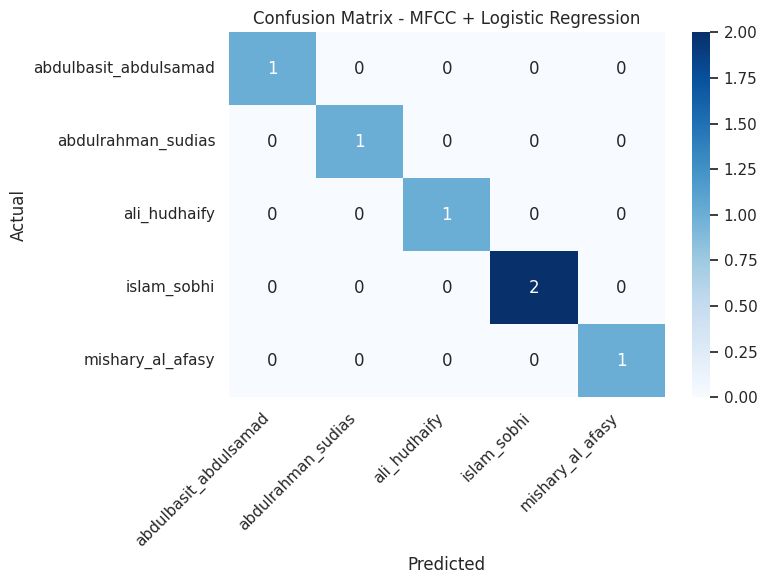

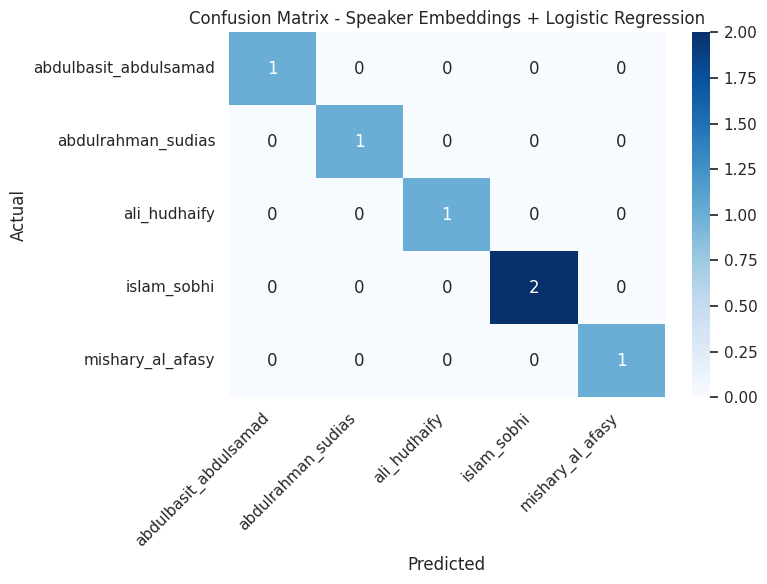

In [16]:
# NEW CELL: Labeled confusion matrices
def plot_labeled_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_labeled_confusion_matrix(y_test_cmp, y_pred_mfcc, le_compare.classes_, "Confusion Matrix - MFCC + Logistic Regression")
plot_labeled_confusion_matrix(y_test_cmp, y_pred_spk, le_compare.classes_, "Confusion Matrix - Speaker Embeddings + Logistic Regression")


In [17]:

# UPDATED CELL: Verse localization evaluation on multiple test files

verse_eval_rows = []

def predict_surah_ayah_from_clip(path, max_duration=30, top_k=5):
    y_audio, sr = load_audio_file(path, sr=SR)
    if len(y_audio) > max_duration * sr:
        y_audio = y_audio[:int(max_duration * sr)]
    transcription = transcribe_audio(y_audio, sr)
    matches = find_best_match(transcription, quran_df, top_k=top_k)
    if matches:
        best = matches[0]
        pred_surah = best["surah"]
        pred_ayah = best["ayah"]
        sim_score = best["similarity"]
    else:
        pred_surah = None
        pred_ayah = None
        sim_score = 0.0
    return transcription, pred_surah, pred_ayah, sim_score, matches

for i in test_idx:
    rec = db["records"][i]
    true_reciter = rec["reciter"]
    label_info = rec.get("label_info", None)

    if label_info is not None:
        true_surah = int(label_info["surah"])
        start_ayah = int(label_info["start_ayah"])
        end_ayah = int(label_info["end_ayah"])
    else:
        true_surah = int(rec["surah"])
        start_ayah = None
        end_ayah = None

    try:
        transcription, pred_surah, pred_ayah, sim_score, matches = predict_surah_ayah_from_clip(
            rec["path"], max_duration=30, top_k=5
        )

        surah_correct = (pred_surah == true_surah)

        if pred_surah == true_surah and pred_ayah is not None and start_ayah is not None and end_ayah is not None:
            ayah_correct = (start_ayah <= pred_ayah <= end_ayah)
        else:
            ayah_correct = False

        overall_correct = surah_correct and ayah_correct

        verse_eval_rows.append({
            "true_reciter": true_reciter,
            "true_surah": true_surah,
            "start_ayah": start_ayah,
            "end_ayah": end_ayah,
            "pred_surah": pred_surah,
            "pred_ayah": pred_ayah,
            "surah_correct": surah_correct,
            "ayah_correct": ayah_correct,
            "overall_correct": overall_correct,
            "similarity": sim_score
        })

    except Exception as e:
        verse_eval_rows.append({
            "true_reciter": true_reciter,
            "true_surah": true_surah,
            "start_ayah": start_ayah,
            "end_ayah": end_ayah,
            "pred_surah": None,
            "pred_ayah": None,
            "surah_correct": False,
            "ayah_correct": False,
            "overall_correct": False,
            "similarity": 0.0
        })

verse_eval_df = pd.DataFrame(verse_eval_rows)

print("=" * 70)
print("VERSE LOCALIZATION EVALUATION")
print("=" * 70)
print(verse_eval_df[[
    "true_reciter", "true_surah", "start_ayah", "end_ayah",
    "pred_surah", "pred_ayah", "surah_correct",
    "ayah_correct", "overall_correct", "similarity"
]].to_string(index=False))


VERSE LOCALIZATION EVALUATION
         true_reciter  true_surah  start_ayah  end_ayah  pred_surah  pred_ayah  surah_correct  ayah_correct  overall_correct  similarity
abdulbasit_abdulsamad         113           1         5           1          1          False         False            False    0.691111
     mishary_al_afasy         100           1        11           1          1          False         False            False    0.691111
         ali_hudhaify         109           1         6           1          1          False         False            False    0.691111
          islam_sobhi          76           1        31          27         30          False         False            False    0.429474
          islam_sobhi          55           1        78          32          7          False         False            False    0.334783
   abdulrahman_sudias         111           1         5          34          1          False         False            False    0.288045


In [18]:
# UPDATED CELL: Surah / Ayah / Overall match accuracy

surah_accuracy = verse_eval_df["surah_correct"].mean()
ayah_accuracy = verse_eval_df["ayah_correct"].mean()
overall_accuracy = verse_eval_df["overall_correct"].mean()

summary_rows = [
    {"Metric": "Surah Accuracy", "Value": surah_accuracy},
    {"Metric": "Ayah Range Accuracy", "Value": ayah_accuracy},
    {"Metric": "Overall Match Accuracy", "Value": overall_accuracy},
    {"Metric": "Test Files Evaluated", "Value": len(verse_eval_df)}
]

verse_summary_df = pd.DataFrame(summary_rows)

print("=" * 70)
print("VERSE LOCALIZATION SUMMARY")
print("=" * 70)
print(verse_summary_df)

print("\nCounts:")
print("Surah Correct  :", int(verse_eval_df["surah_correct"].sum()))
print("Ayah Correct   :", int(verse_eval_df["ayah_correct"].sum()))
print("Overall Correct:", int(verse_eval_df["overall_correct"].sum()))


VERSE LOCALIZATION SUMMARY
                   Metric  Value
0          Surah Accuracy    0.0
1     Ayah Range Accuracy    0.0
2  Overall Match Accuracy    0.0
3    Test Files Evaluated    6.0

Counts:
Surah Correct  : 0
Ayah Correct   : 0
Overall Correct: 0


In [19]:

# UPDATED CELL: Final combined results
final_results = comparison_df.copy()

final_results.loc[len(final_results)] = {
    "Model": "Verse Localization (Whisper + Text Matching)",
    "Accuracy": overall_accuracy,
    "Precision": None,
    "Recall": None,
    "F1-score": None
}

print("=" * 70)
print("FINAL RESULTS TABLE")
print("=" * 70)
print(final_results.round(4))


FINAL RESULTS TABLE
                                          Model  Accuracy  Precision  Recall  \
0                    MFCC + Logistic Regression       1.0        1.0     1.0   
1      Speaker Embeddings + Logistic Regression       1.0        1.0     1.0   
2  Verse Localization (Whisper + Text Matching)       0.0        NaN     NaN   

   F1-score  
0       1.0  
1       1.0  
2       NaN  


In [20]:
count = sum(1 for r in db["records"] if r.get("label_info") is not None)
print("Labels attached:", count, "/", len(db["records"]))

Labels attached: 30 / 30


In [21]:
import os

for rec in db["records"][:10]:
    print("FILE:", os.path.basename(rec["path"]))
    print("RECITER:", rec["reciter"])
    print("LABEL:", rec.get("label_info"))
    print("-" * 50)

FILE: 067.mp3
RECITER: abdulbasit_abdulsamad
LABEL: {'surah': 67, 'start_ayah': 1, 'end_ayah': 30}
--------------------------------------------------
FILE: 109.mp3
RECITER: abdulbasit_abdulsamad
LABEL: {'surah': 109, 'start_ayah': 1, 'end_ayah': 6}
--------------------------------------------------
FILE: 110.mp3
RECITER: abdulbasit_abdulsamad
LABEL: {'surah': 110, 'start_ayah': 1, 'end_ayah': 3}
--------------------------------------------------
FILE: 112.mp3
RECITER: abdulbasit_abdulsamad
LABEL: {'surah': 112, 'start_ayah': 1, 'end_ayah': 4}
--------------------------------------------------
FILE: 113.mp3
RECITER: abdulbasit_abdulsamad
LABEL: {'surah': 113, 'start_ayah': 1, 'end_ayah': 5}
--------------------------------------------------
FILE: 114.mp3
RECITER: abdulbasit_abdulsamad
LABEL: {'surah': 114, 'start_ayah': 1, 'end_ayah': 6}
--------------------------------------------------
FILE: 112.mp3
RECITER: abdulrahman_sudias
LABEL: {'surah': 112, 'start_ayah': 1, 'end_ayah': 4}
----

In [22]:
import os

missing = []
for rec in db["records"]:
    if rec.get("label_info") is None:
        missing.append((os.path.basename(rec["path"]), rec["reciter"]))

print("Missing labels:", len(missing))
for item in missing:
    print(item)

Missing labels: 0


In [23]:
import os

for rec in db["records"][:10]:
    key = (os.path.basename(rec["path"]).strip(), str(rec["reciter"]).strip())
    print(key, "->", label_map.get(key))

('067.mp3', 'abdulbasit_abdulsamad') -> {'surah': 67, 'start_ayah': 1, 'end_ayah': 30}
('109.mp3', 'abdulbasit_abdulsamad') -> {'surah': 109, 'start_ayah': 1, 'end_ayah': 6}
('110.mp3', 'abdulbasit_abdulsamad') -> {'surah': 110, 'start_ayah': 1, 'end_ayah': 3}
('112.mp3', 'abdulbasit_abdulsamad') -> {'surah': 112, 'start_ayah': 1, 'end_ayah': 4}
('113.mp3', 'abdulbasit_abdulsamad') -> {'surah': 113, 'start_ayah': 1, 'end_ayah': 5}
('114.mp3', 'abdulbasit_abdulsamad') -> {'surah': 114, 'start_ayah': 1, 'end_ayah': 6}
('112.mp3', 'abdulrahman_sudias') -> {'surah': 112, 'start_ayah': 1, 'end_ayah': 4}
('110.mp3', 'abdulrahman_sudias') -> {'surah': 110, 'start_ayah': 1, 'end_ayah': 3}
('111.mp3', 'abdulrahman_sudias') -> {'surah': 111, 'start_ayah': 1, 'end_ayah': 5}
('113.mp3', 'abdulrahman_sudias') -> {'surah': 113, 'start_ayah': 1, 'end_ayah': 5}


In [24]:
import requests
def get_tafsir_with_grok(surah, ayah, verse_text, tafsir_style="Al-Muyassar (Simplified)",
                         api_key="your_real_key_here"):
    """
    Generate tafsir using Groq API with different scholarly styles
    """
    url = "https://api.groq.com/openai/v1/chat/completions"

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }

    # Define different tafsir styles
    style_prompts = {
        "Al-Muyassar (Simplified)": "Provide a simplified, concise tafsir in 2-3 sentences.",
        "As-Sa'di (Balanced)": "Provide a balanced tafsir with practical lessons in 3-4 sentences.",
        "Ibn Kathir (Detailed)": "Provide a detailed tafsir with historical context and hadith connections in 4-6 sentences."
    }

    style_instruction = style_prompts.get(tafsir_style, style_prompts["Al-Muyassar (Simplified)"])

    prompt = f"""You are an Islamic scholar providing tafsir (interpretation) of the Quran.

Surah: {surah}
Ayah: {ayah}
Verse Text (Arabic): {verse_text}

{style_instruction}

Provide the tafsir in English. Be respectful and accurate."""

    payload = {
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "model": "llama-3.3-70b-versatile",  # ← Groq's model
        "temperature": 0.7,
        "max_tokens": 500
    }

    try:
        response = requests.post(url, headers=headers, json=payload, timeout=30)
        response.raise_for_status()

        data = response.json()
        tafsir = data['choices'][0]['message']['content']
        return tafsir.strip()

    except requests.exceptions.HTTPError as e:
        error_detail = ""
        try:
            error_detail = e.response.json()
        except:
            error_detail = e.response.text
        return f"Error fetching tafsir: {e.response.status_code} - {error_detail}"
    except requests.exceptions.RequestException as e:
        return f"Error fetching tafsir: {str(e)}"
    except (KeyError, IndexError) as e:
        return f"Error parsing response: {str(e)}"

def infer_gradio(file_path, tafsir_style):
    try:
        rec_preds, transcription, matches = predict_from_clip(
            file_path,
            top_k=3,
            max_duration=30
        )

        # Reciter identification
        reciter_text = "🎤 RECITER IDENTIFICATION:\n\n"
        for i, (r, p) in enumerate(rec_preds, 1):
            reciter_text += f"{i}. {r.replace('_', ' ').title()}: {p:.1%}\n"

        # Transcription + verse detection
        matches_text = f"📝 TRANSCRIPTION:\n{transcription}\n\n"
        matches_text += "="*60 + "\n"
        matches_text += f"📖 IDENTIFIED VERSES + TAFSIR ({tafsir_style}):\n\n"

        if matches:
            for i, m in enumerate(matches[:3], 1):
                surah = m["surah"]
                ayah = m["ayah"]
                verse_text = m["text"]

                tafsir = get_tafsir_with_grok(surah, ayah, verse_text, tafsir_style)

                matches_text += (
                    f"{i}. Surah {surah} - {m['surah_name']}, Ayah {ayah}\n"
                    f"   Confidence: {m['similarity']:.1%}\n"
                    f"   Text: {m['text'][:100]}...\n\n"
                    f"📚 **Tafsir ({tafsir_style}):**\n{tafsir}\n"
                    f"{'-'*60}\n\n"
                )
        else:
            matches_text += "⚠️ No matching verses found.\n"

        return reciter_text, matches_text

    except Exception as e:
        import traceback
        error_msg = f"❌ ERROR: {str(e)}\n\n"
        error_msg += "Traceback:\n" + traceback.format_exc()
        return error_msg, ""


# Gradio Interface
demo = gr.Interface(
    fn=infer_gradio,
    inputs=[
        gr.Audio(type="filepath", label="Upload Quran Recitation"),
        gr.Radio(
            choices=[
                "Al-Muyassar (Simplified)",
                "As-Sa'di (Balanced)",
                "Ibn Kathir (Detailed)"
            ],
            value="Al-Muyassar (Simplified)",
            label="Select Tafsir Style"
        )
    ],
    outputs=[
        gr.Textbox(label="Reciter Identification", lines=5),
        gr.Textbox(label="Surah, Ayah & Tafsir", lines=25)
    ],
    title="🕌 Quran Reciter & Verse Identifier",
    description="",
    examples=None,
    cache_examples=False
)

demo.launch(share=True, inbrowser=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://77e8d48fbad5528c7a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
